In [1]:
import numpy as np 
import pandas as pd
from sklearn.datasets import fetch_california_housing

import matplotlib.pyplot as plt 
import seaborn as sns
sns.set_theme(style='white')

import math
import scipy.stats as stats

In [2]:
try:
    data = fetch_california_housing(as_frame=True)
    df = data.frame
except HTTPError:
    print('Error')

In [3]:
print(f'Data Shape: {df.shape[0]} Row, {df.shape[1]} Colmn')
print('\n---- First 5 Line ----')
display(df.head())

Data Shape: 20640 Row, 9 Colmn

---- First 5 Line ----


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print('\n ---- Data Type -----')
print(df.info())

print('\n ----- Missing Value -----')
print(df.isnull().sum())


 ---- Data Type -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

 ----- Missing Value -----
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
print('\n ----- Statical Summary of Dataset ------')
display(df.describe().T)

print('\n ----- Correlation Matrix ------')
correlation = df.corr()
correlation


 ----- Statical Summary of Dataset ------


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010



 ----- Correlation Matrix ------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


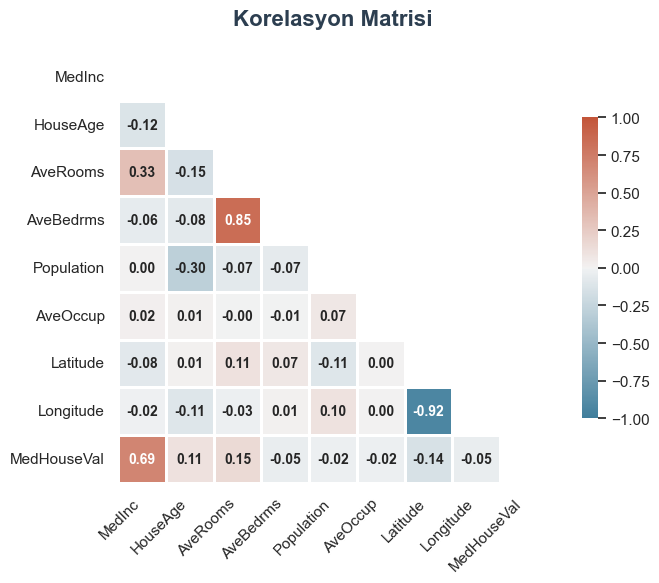

In [6]:
mask = np.triu(np.ones_like(correlation, dtype=bool))
plt.figure(figsize=(8, 6))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    correlation,
    mask=mask,   
    cmap=cmap,  
    vmax=1.0,  
    vmin=-1.0,  
    center=0,  
    square=True,  
    linewidths=0.75,  
    cbar_kws={"shrink": 0.7},  
    annot=True,  
    fmt=".2f",  
    annot_kws={
        "size": 10,
        "weight": "bold",
    },  
)


plt.title(
    "Korelasyon Matrisi", fontsize=16, pad=20, fontweight="bold", color="#2c3e50"
)
plt.xticks(
    rotation=45, ha="right", fontsize=11
)  
plt.yticks(rotation=0, fontsize=11)  
plt.tight_layout()
plt.show()

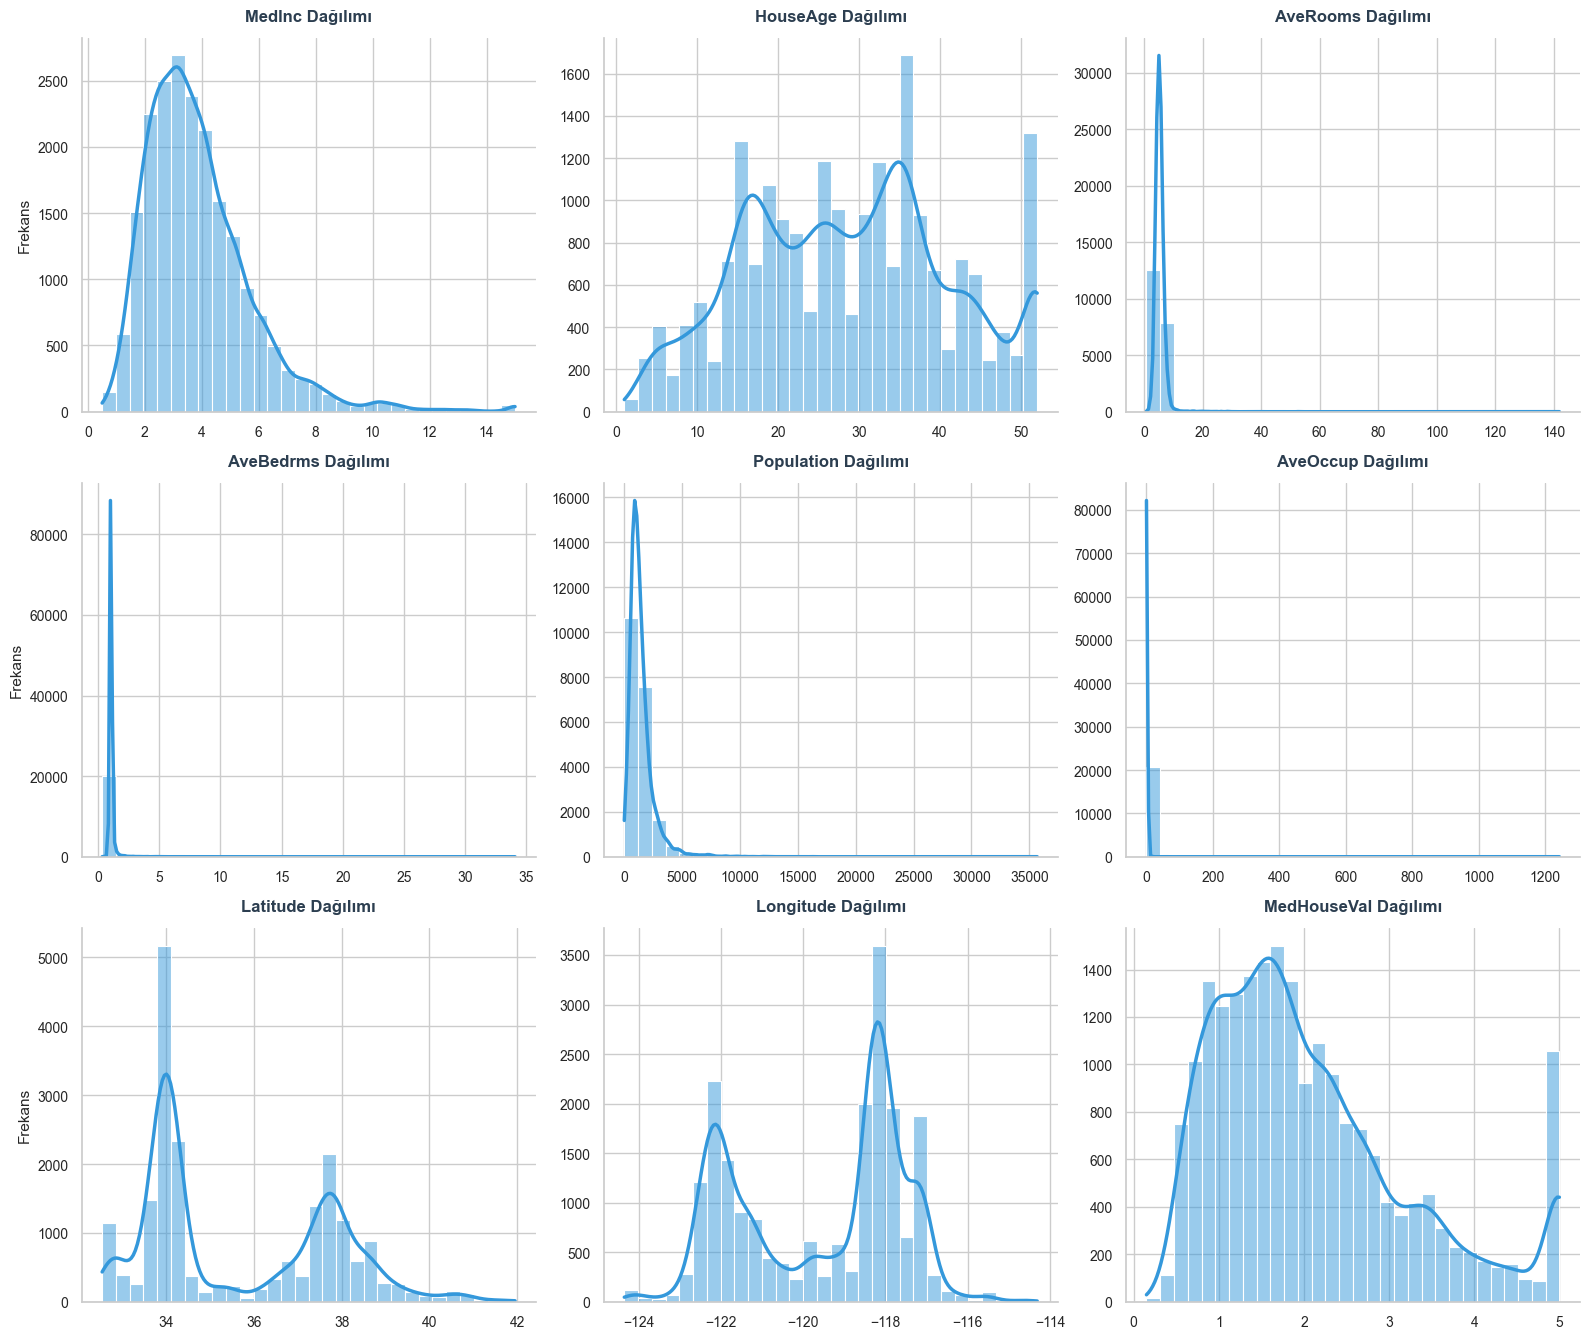

In [7]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# 2. Sütunların Seçilmesi ve Izgara (Grid) Yapısının Hesaplanması
num_cols = df.select_dtypes(include=["float64"]).columns
n_features = len(num_cols)

n_cols_grid = 3  # Yan yana kaç grafik listelenecek
n_rows_grid = math.ceil(n_features / n_cols_grid)  # Gerekli satır sayısı

# 3. Figür ve Eksenlerin (Axes) Tanımlanması
fig, axes = plt.subplots(
    nrows=n_rows_grid, ncols=n_cols_grid, figsize=(16, n_rows_grid * 4.5)
)

# Eksenleri kolay döngüye sokabilmek için tek boyutlu diziye düzleştiriyoruz
axes = axes.flatten()

# 4. Grafiklerin Çizilmesi
for i, col in enumerate(num_cols):
    ax = axes[i]

    # Histogram ve Yoğunluk Grafiği
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=ax,
        color="#3498db",  # Modern bir mavi tonu
        edgecolor="white",  # Daha temiz bir görünüm için beyaz kenarlık
        line_kws={"linewidth": 2.5},  # KDE çizgi kalınlığı
    )

    # Estetik dokunuşlar
    ax.set_title(f"{col} Dağılımı", fontweight="bold", pad=12, color="#2c3e50")
    ax.set_xlabel("")
    ax.set_ylabel("Frekans" if i % n_cols_grid == 0 else "")  # Sadece en soldaki grafiklerde "Frekans" yazar
    ax.spines[["top", "right"]].set_visible(
        False
    )  # Üst ve sağ çizgileri kaldırarak modernleştirme

# 5. Boş Kalan Eksenlerin Kapatılması
# Eğer 7 değişkeniniz varsa, 3x3'lük matriste son 2 kare boş kalır. Onları gizliyoruz:
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Grafik Yerleşimi ve Gösterim
plt.tight_layout()
plt.show()

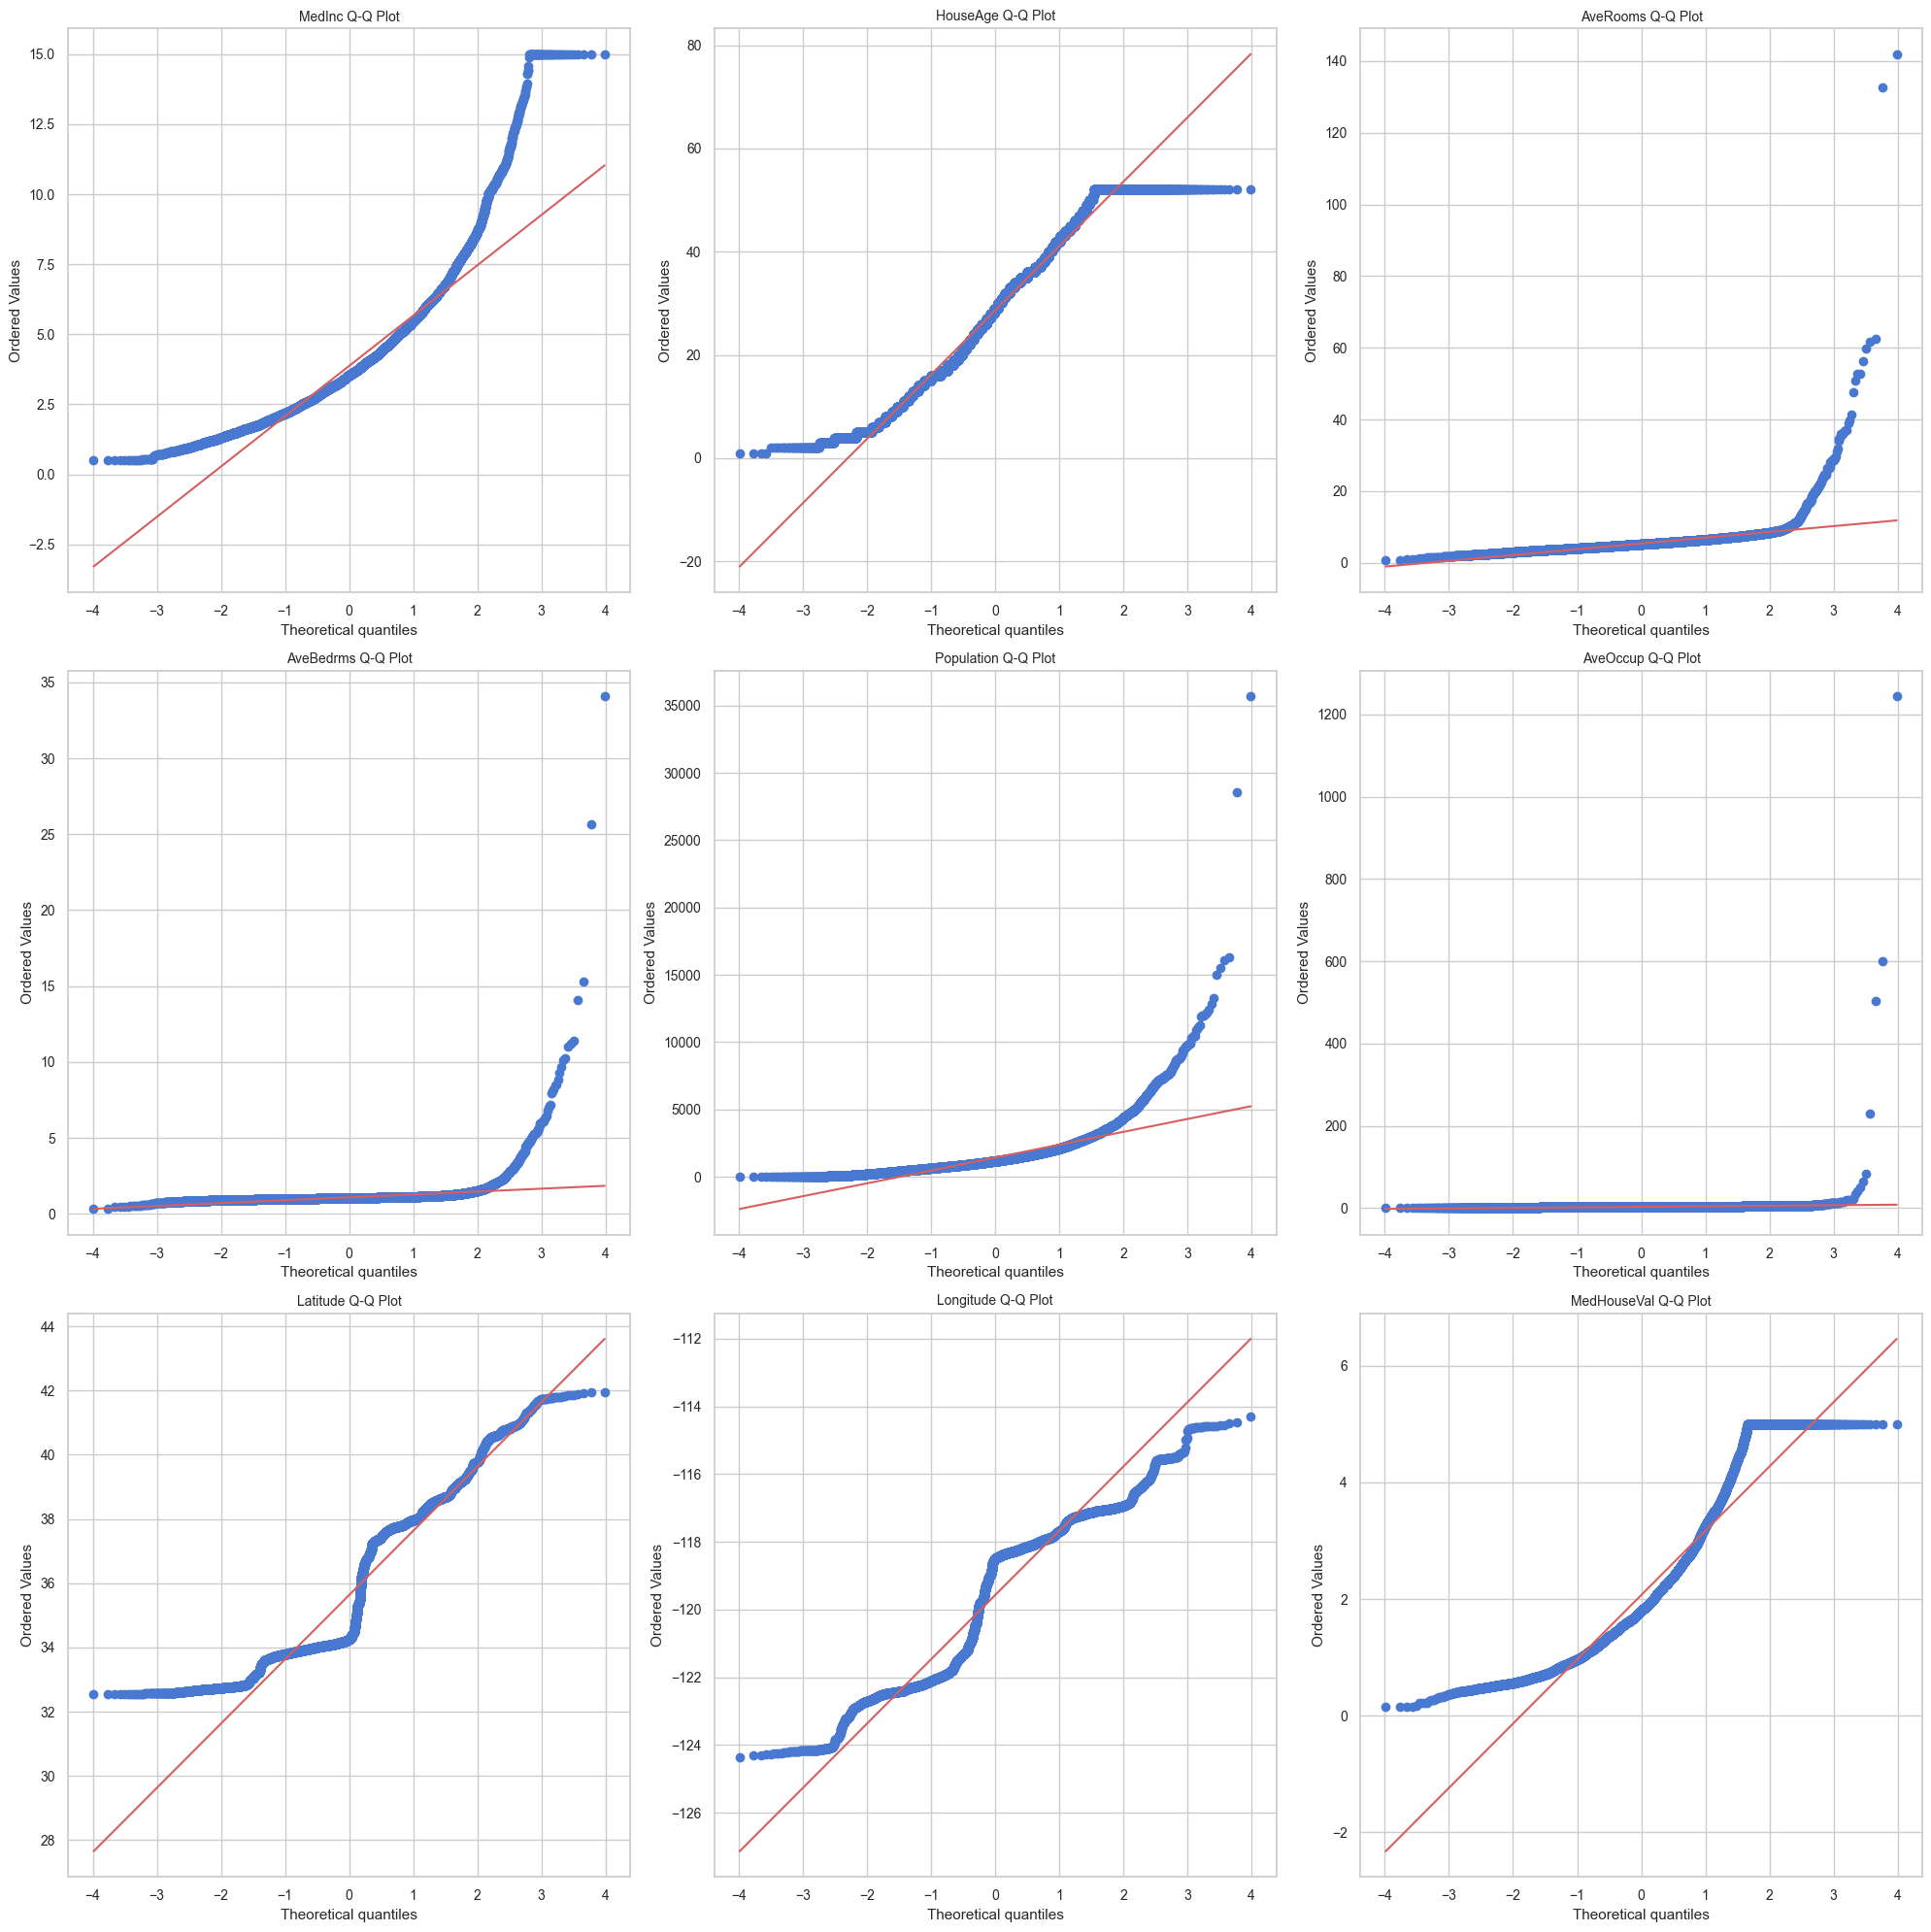

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(20,20))

axes = axes.ravel()

for i, col in enumerate(num_cols):

    stats.probplot(
        df[col].dropna(),
        dist='norm',
        plot=axes[i]
    )

    axes[i].set_title(
        f'{col} Q-Q Plot',
        fontsize=10
    )

# Boş kalan eksenleri sil
for j in range(
    len(num_cols),
    len(axes)
):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

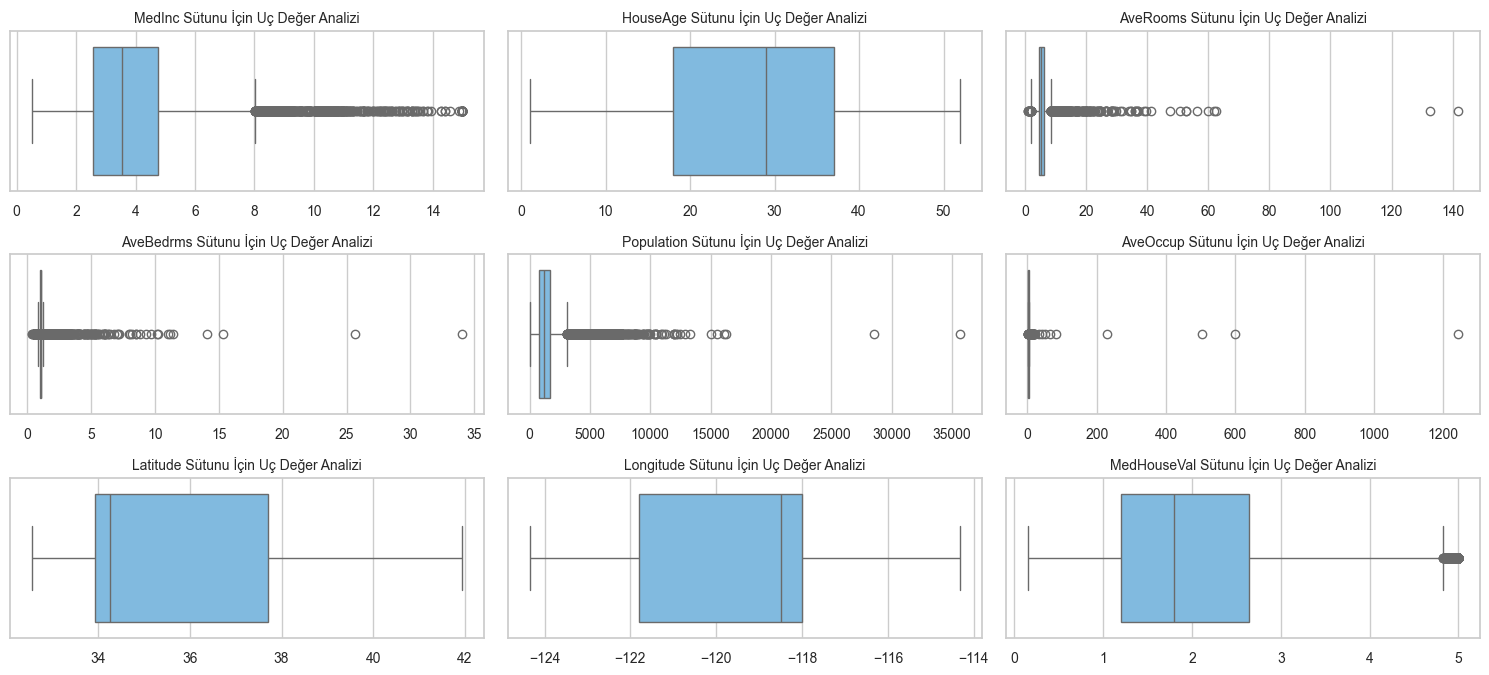

In [9]:
plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 3, i)
    sns.boxplot(x=df[col], color="#71bdef")
    plt.title(f'{col} Sütunu İçin Uç Değer Analizi', fontsize=10)
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

print(f'X_train Shape: {X_train.shape} | y_train Shape {y_train.shape}')
print(f'X_test Shape: {X_test.shape} | y_test Shape {y_test.shape}')

X_train Shape: (16512, 8) | y_train Shape (16512,)
X_test Shape: (4128, 8) | y_test Shape (4128,)


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = RandomForestRegressor(random_state=42, n_estimators=200)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
    
print(f"=== Sonuçlar ===")
print(f"MAE  (Ortalama Mutlak Hata): {mae:.4f}")
print(f"RMSE (Hata Kareler Ort. Kökü): {rmse:.4f}")
print(f"R2 Score (Açıklayıcılık Oranı): {r2:.4f}\n")

=== Sonuçlar ===
MAE  (Ortalama Mutlak Hata): 0.3268
RMSE (Hata Kareler Ort. Kökü): 0.5040
R2 Score (Açıklayıcılık Oranı): 0.8062



In [12]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
    
print(f"=== Sonuçlar ===")
print(f"MAE  (Ortalama Mutlak Hata): {mae:.4f}")
print(f"RMSE (Hata Kareler Ort. Kökü): {rmse:.4f}")
print(f"R2 Score (Açıklayıcılık Oranı): {r2:.4f}\n")


=== Sonuçlar ===
MAE  (Ortalama Mutlak Hata): 0.2979
RMSE (Hata Kareler Ort. Kökü): 0.4561
R2 Score (Açıklayıcılık Oranı): 0.8412



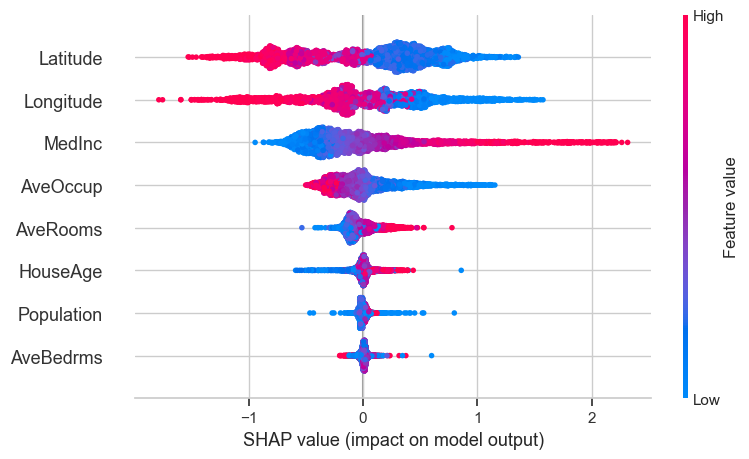

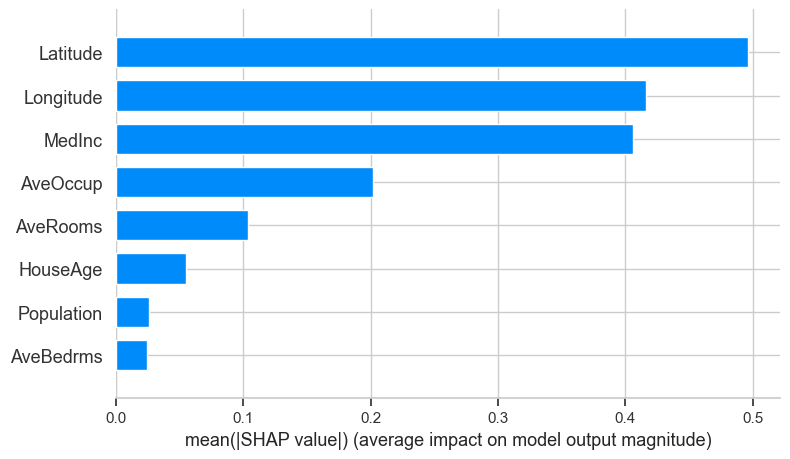

In [14]:
import shap

explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_test)

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)